In [2]:
!pip install opencv--python 

Defaulting to user installation because normal site-packages is not writeable
  Obtaining dependency information for opencv--python from https://files.pythonhosted.org/packages/fa/80/eb88edc2e2b11cd2dd2e56f1c80b5784d11d6e6b7f04a1145df64df40065/opencv_python-4.12.0.88-cp37-abi3-win_amd64.whl.metadata
  Using cached opencv_python-4.12.0.88-cp37-abi3-win_amd64.whl.metadata (19 kB)
  Obtaining dependency information for numpy<2.3.0,>=2 from https://files.pythonhosted.org/packages/31/0a/f354fb7176b81747d870f7991dc763e157a934c717b67b58456bc63da3df/numpy-2.2.6-cp311-cp311-win_amd64.whl.metadata
     ---------------------------------------- 0.0/60.8 kB ? eta -:--:--
     ---------------------------------------- 60.8/60.8 kB 3.2 MB/s eta 0:00:00
   ---------------------------------------- 0.0/39.0 MB ? eta -:--:--
   ---------------------------------------- 0.2/39.0 MB 6.3 MB/s eta 0:00:07
   ---------------------------------------- 0.2/39.0 MB 6.3 MB/s eta 0:00:07
   --------------------------

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
gensim 4.3.0 requires FuzzyTM>=0.4.0, which is not installed.
tables 3.8.0 requires blosc2~=2.0.0, which is not installed.
tables 3.8.0 requires cython>=0.29.21, which is not installed.
numba 0.57.1 requires numpy<1.25,>=1.21, but you have numpy 2.2.6 which is incompatible.
scipy 1.11.1 requires numpy<1.28.0,>=1.21.6, but you have numpy 2.2.6 which is incompatible.


In [34]:
!pip install "numpy<2.0"

Defaulting to user installation because normal site-packages is not writeable
  Obtaining dependency information for numpy<2.0 from https://files.pythonhosted.org/packages/3f/6b/5610004206cf7f8e7ad91c5a85a8c71b2f2f8051a0c0c4d5916b76d6cbb2/numpy-1.26.4-cp311-cp311-win_amd64.whl.metadata
     ---------------------------------------- 0.0/61.0 kB ? eta -:--:--
     ------------ ------------------------- 20.5/61.0 kB 217.9 kB/s eta 0:00:01
     ------------------------- ------------ 41.0/61.0 kB 393.8 kB/s eta 0:00:01
     -------------------------------------- 61.0/61.0 kB 461.8 kB/s eta 0:00:00
   ---------------------------------------- 0.0/15.8 MB ? eta -:--:--
   ---------------------------------------- 0.1/15.8 MB 4.2 MB/s eta 0:00:04
   - -------------------------------------- 0.7/15.8 MB 10.9 MB/s eta 0:00:02
   - -------------------------------------- 0.7/15.8 MB 10.9 MB/s eta 0:00:02
   - -------------------------------------- 0.7/15.8 MB 4.5 MB/s eta 0:00:04
   - ----------------

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
ERROR: Could not install packages due to an OSError: [WinError 5] Access is denied: 'C:\\Users\\TEMP.MITS.022\\AppData\\Roaming\\Python\\Python311\\site-packages\\~umpy.libs\\libscipy_openblas64_-13e2df515630b4a41f92893938845698.dll'
Check the permissions.



In [5]:
!pip install --upgrade matplotlib

Defaulting to user installation because normal site-packages is not writeable
  Obtaining dependency information for matplotlib from https://files.pythonhosted.org/packages/6f/d3/a4bbc01c237ab710a1f22b4da72f4ff6d77eb4c7735ea9811a94ae239067/matplotlib-3.10.8-cp311-cp311-win_amd64.whl.metadata
     ---------------------------------------- 0.0/52.8 kB ? eta -:--:--
     ------- -------------------------------- 10.2/52.8 kB ? eta -:--:--
     ----------------------------- -------- 41.0/52.8 kB 393.8 kB/s eta 0:00:01
     -------------------------------------- 52.8/52.8 kB 453.1 kB/s eta 0:00:00
   ---------------------------------------- 0.0/8.1 MB ? eta -:--:--
    --------------------------------------- 0.1/8.1 MB 3.6 MB/s eta 0:00:03
    --------------------------------------- 0.1/8.1 MB 4.3 MB/s eta 0:00:02
    --------------------------------------- 0.2/8.1 MB 1.3 MB/s eta 0:00:07
    --------------------------------------- 0.2/8.1 MB 1.3 MB/s eta 0:00:07
    -------------------------

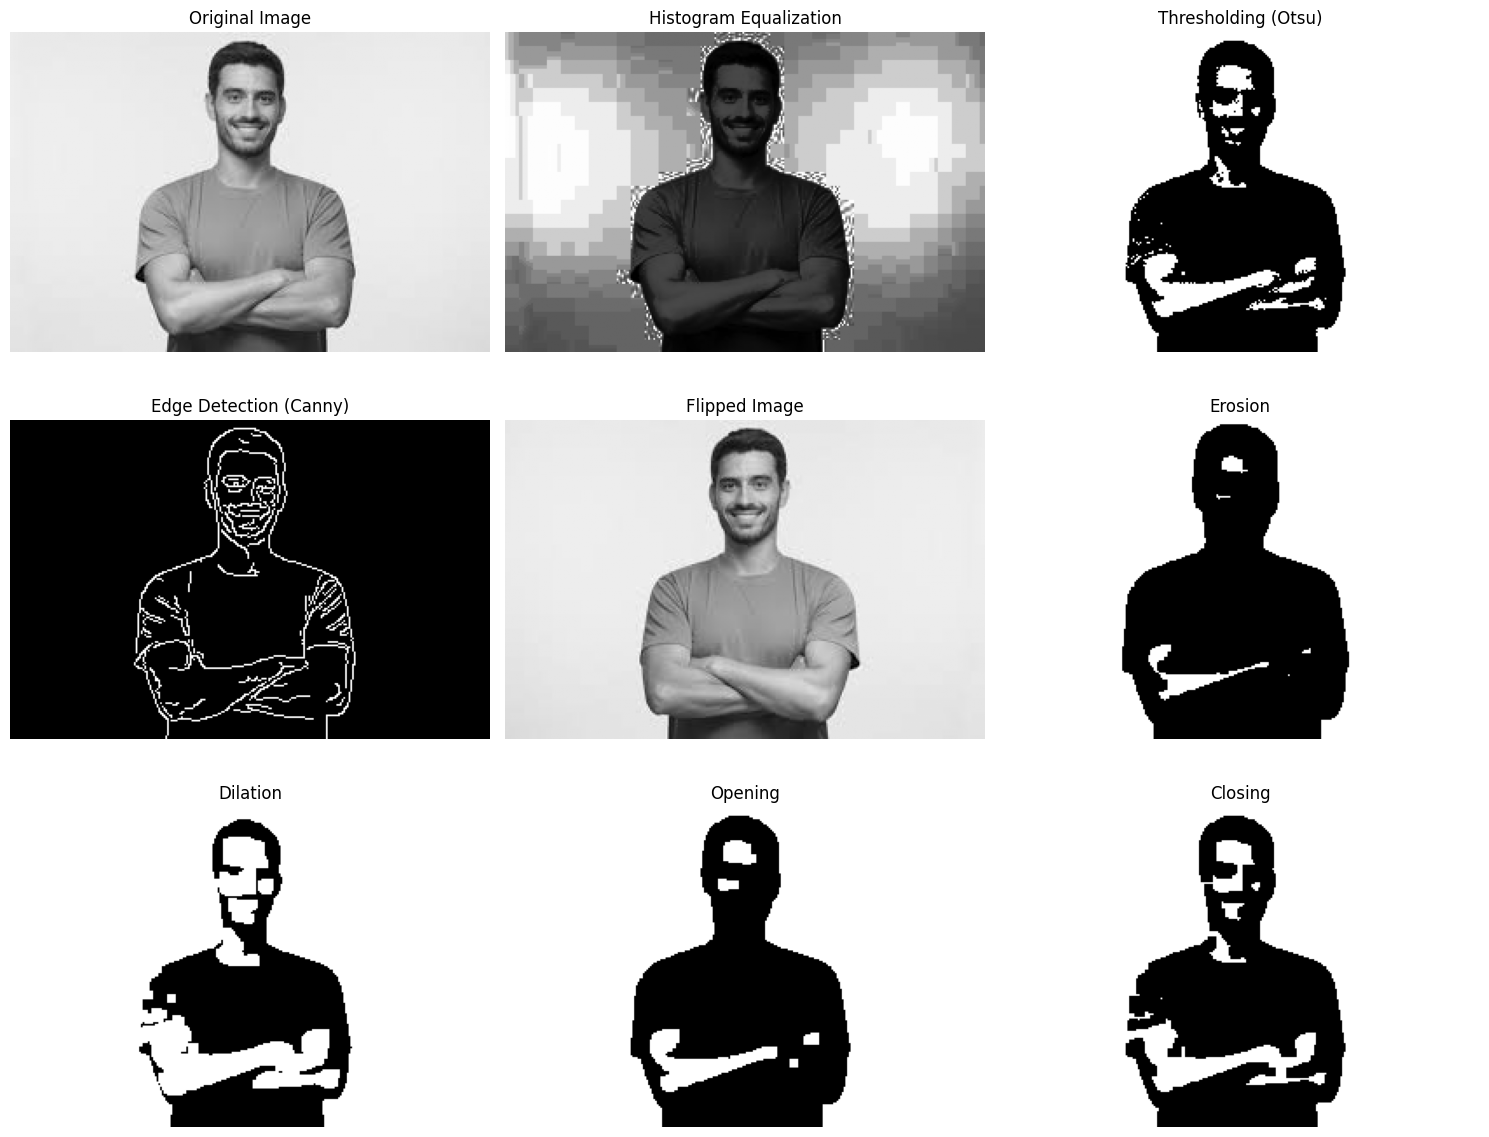

In [6]:
import cv2
import matplotlib.pyplot as plt
import numpy as np

# Read image
img = cv2.imread("example.jpg", cv2.IMREAD_GRAYSCALE)

# Preprocessing
equalized_image = cv2.equalizeHist(img)
_, thresholded_image = cv2.threshold(
    img, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU
)
edges = cv2.Canny(img, 100, 200)
flipped_image = cv2.flip(img, 1)

# Morphological operations
kernel = np.ones((5, 5), np.uint8)
erosion  = cv2.erode(thresholded_image, kernel, iterations=1)
dilation = cv2.dilate(thresholded_image, kernel, iterations=1)
opening  = cv2.morphologyEx(thresholded_image, cv2.MORPH_OPEN, kernel)
closing  = cv2.morphologyEx(thresholded_image, cv2.MORPH_CLOSE, kernel)

# Create ONE figure
plt.figure(figsize=(15, 12))

images = [
    img,
    equalized_image,
    thresholded_image,
    edges,
    flipped_image,
    erosion,
    dilation,
    opening,
    closing
]

titles = [
    "Original Image",
    "Histogram Equalization",
    "Thresholding (Otsu)",
    "Edge Detection (Canny)",
    "Flipped Image",
    "Erosion",
    "Dilation",
    "Opening",
    "Closing"
]

# Plot all images
for i in range(9):
    plt.subplot(3, 3, i + 1)
    plt.imshow(images[i], cmap="gray")
    plt.title(titles[i])
    plt.axis("off")

plt.tight_layout()
plt.show()


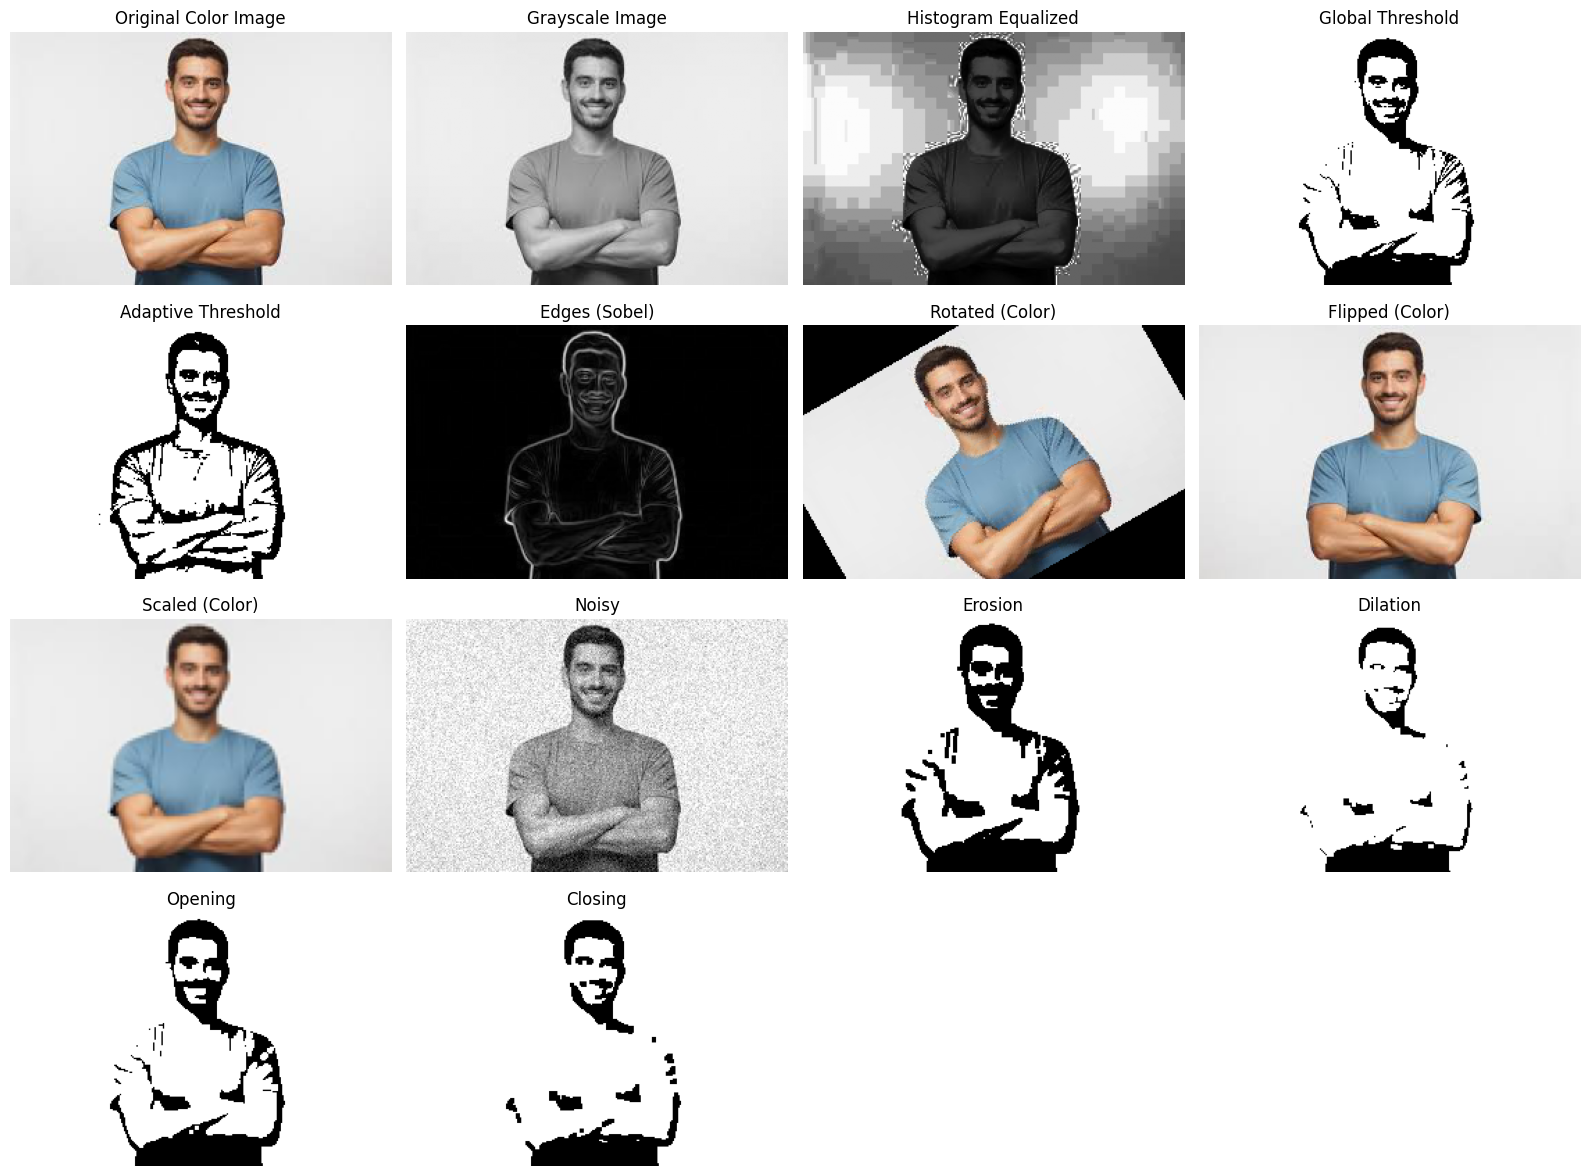

In [1]:
import numpy as np
from PIL import Image
from scipy.ndimage import convolve, uniform_filter, minimum_filter, maximum_filter
import matplotlib.pyplot as plt

# -----------------------------
# Load ORIGINAL COLOR Image
# -----------------------------
color_img = Image.open("example.jpg")
color_np = np.array(color_img)

# -----------------------------
# Convert to Grayscale
# -----------------------------
gray_img = color_img.convert("L")
gray_np = np.array(gray_img)

# -----------------------------
# 1. Histogram Equalization
# -----------------------------
hist, _ = np.histogram(gray_np.flatten(), 256, [0,256])
cdf = hist.cumsum()
cdf = (cdf - cdf.min()) * 255 / (cdf.max() - cdf.min())
cdf = cdf.astype(np.uint8)
hist_eq = cdf[gray_np]

# -----------------------------
# 2. Thresholding
# -----------------------------
binary = np.where(gray_np > 128, 255, 0).astype(np.uint8)

mean = uniform_filter(gray_np, size=15)
adaptive = np.where(gray_np > mean - 5, 255, 0).astype(np.uint8)

# -----------------------------
# 3. Edge Detection (Sobel)
# -----------------------------
Gx = np.array([[-1,0,1],[-2,0,2],[-1,0,1]])
Gy = np.array([[1,2,1],[0,0,0],[-1,-2,-1]])

Ix = convolve(gray_np.astype(float), Gx)
Iy = convolve(gray_np.astype(float), Gy)

edges = np.hypot(Ix, Iy)
edges = (edges / edges.max()) * 255
edges = edges.astype(np.uint8)

# -----------------------------
# 4. Data Augmentation
# -----------------------------
rotated = color_img.rotate(30)
flipped = color_img.transpose(Image.FLIP_LEFT_RIGHT)
scaled = color_img.resize((color_img.width//2, color_img.height//2))

noise = np.random.normal(0, 20, gray_np.shape)
noisy = np.clip(gray_np + noise, 0, 255).astype(np.uint8)

# -----------------------------
# 5. Morphological Operations
# -----------------------------
eroded = minimum_filter(binary, size=3)
dilated = maximum_filter(binary, size=3)
opened = maximum_filter(eroded, size=3)
closed = minimum_filter(dilated, size=3)

# -----------------------------
# Display All Images
# -----------------------------
titles = [
    "Original Color Image","Grayscale Image","Histogram Equalized","Global Threshold","Adaptive Threshold","Edges (Sobel)","Rotated (Color)","Flipped (Color)","Scaled (Color)","Noisy","Erosion","Dilation","Opening","Closing"
]

images = [
    color_np,gray_np,hist_eq,binary,adaptive,edges,np.array(rotated),np.array(flipped),np.array(scaled),noisy,eroded,dilated,opened,closed
]

plt.figure(figsize=(16, 12))

for i in range(len(images)):
    plt.subplot(4, 4, i + 1)
    
    if images[i].ndim == 3:
        plt.imshow(images[i])
    else:
        plt.imshow(images[i], cmap="gray")
    
    plt.title(titles[i])
    plt.axis("off")

plt.tight_layout()
plt.show()